In [ ]:
# Anomaly Detection Using Isolation Forest

**Objective:** Detect unusual energy consumption patterns in Building_17 using unsupervised machine learning.

**Goal:** Identify potential waste events, meter errors, or equipment issues.

**Model:** Isolation Forest (Scikit-learn)
**Building:** 17

In [2]:
# ============================================================
# SETUP & IMPORTS
# ============================================================

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# ============================================================
# DATABASE CONNECTION
# ============================================================

conn = psycopg2.connect(
    host="localhost",
    database="energy_intelligence_project1",
    user="postgres",
    password="your_password"  
)

print("Connected to PostgreSQL successfully")

Connected to PostgreSQL successfully


In [4]:
# ============================================================
# LOAD DATA FOR BUILDING_17
# ============================================================

query = """
SELECT 
    timestamp,
    energy_kwh,
    demand_kw,
    temperature_celsius,
    humidity_percent
FROM energy_readings
WHERE building_id = 17
ORDER BY timestamp;
"""

df = pd.read_sql(query, conn)

print(f"Loaded {len(df):,} rows of data")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

conn.close()

Loaded 70,081 rows of data
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [5]:
# ============================================================
# DATA OVERVIEW
# ============================================================

print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

print(f"Total rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
print(df.head())

DATA OVERVIEW
Total rows: 70,081
Columns: ['timestamp', 'energy_kwh', 'demand_kw', 'temperature_celsius', 'humidity_percent']

Data Types:
timestamp              datetime64[ns]
energy_kwh                    float64
demand_kw                     float64
temperature_celsius           float64
humidity_percent              float64
dtype: object

Missing Values:
timestamp              0
energy_kwh             0
demand_kw              0
temperature_celsius    0
humidity_percent       0
dtype: int64

First 5 rows:
            timestamp  energy_kwh  demand_kw  temperature_celsius  \
0 2023-01-01 00:00:00        0.29       1.15                 -2.3   
1 2023-01-01 00:15:00        0.20       0.86                 -2.3   
2 2023-01-01 00:30:00        0.28       1.23                 -2.3   
3 2023-01-01 00:45:00        0.24       0.98                 -2.3   
4 2023-01-01 01:00:00        0.25       0.99                 -2.3   

   humidity_percent  
0              78.2  
1              78.2  
2     

In [6]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Extract time-based features
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df['day_of_week'] = pd.to_datetime(df['timestamp']).dt.dayofweek
df['month'] = pd.to_datetime(df['timestamp']).dt.month

print("Features added:")
print(f"  - hour: {df['hour'].min()} to {df['hour'].max()}")
print(f"  - day_of_week: {df['day_of_week'].min()} to {df['day_of_week'].max()}")
print(f"  - month: {df['month'].min()} to {df['month'].max()}")

# Feature columns for model
features = [
    'energy_kwh',
    'demand_kw',
    'temperature_celsius',
    'humidity_percent',
    'hour',
    'day_of_week'
]

X = df[features]

print(f"\nFeatures shape: {X.shape}")

Features added:
  - hour: 0 to 23
  - day_of_week: 0 to 6
  - month: 1 to 12

Features shape: (70081, 6)


In [7]:
# ============================================================
# SCALE FEATURES
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully")

Features scaled successfully


In [8]:
# ============================================================
# TRAIN ISOLATION FOREST MODEL
# ============================================================

model = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_estimators=100,
    max_samples='auto'
)

df['anomaly'] = model.fit_predict(X_scaled)

print("Isolation Forest model trained successfully")

Isolation Forest model trained successfully


In [9]:
# ============================================================
# RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("ANOMALY DETECTION RESULTS")
print("=" * 60)

total_readings = len(df)
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

print(f"Total readings analyzed: {total_readings:,}")
print(f"Normal readings: {len(normal):,}")
print(f"Anomalies detected: {len(anomalies):,}")
print(f"Anomaly rate: {len(anomalies)/total_readings*100:.2f}%")

print("\nAnomalies by Hour of Day:")
print(anomalies['hour'].value_counts().sort_index().head(10))

print("\nAnomalies by Day of Week:")
print(anomalies['day_of_week'].value_counts().sort_index())

ANOMALY DETECTION RESULTS
Total readings analyzed: 70,081
Normal readings: 69,380
Anomalies detected: 701
Anomaly rate: 1.00%

Anomalies by Hour of Day:
hour
0     41
1      1
6      1
7      4
11     3
12     4
13     9
14    29
15    57
16    85
Name: count, dtype: int64

Anomalies by Day of Week:
day_of_week
0    219
1     95
2     89
3     95
4    147
5      3
6     53
Name: count, dtype: int64


In [10]:
# ============================================================
# ANOMALIES SAMPLE
# ============================================================

print("=" * 60)
print("ANOMALIES SAMPLE (First 10)")
print("=" * 60)

print(anomalies[['timestamp', 'energy_kwh', 'hour', 'day_of_week']].head(10))

ANOMALIES SAMPLE (First 10)
              timestamp  energy_kwh  hour  day_of_week
0   2023-01-01 00:00:00        0.29     0            6
1   2023-01-01 00:15:00        0.20     0            6
2   2023-01-01 00:30:00        0.28     0            6
159 2023-01-02 15:45:00        3.83    15            0
161 2023-01-02 16:15:00        3.99    16            0
162 2023-01-02 16:30:00        4.03    16            0
164 2023-01-02 17:00:00        4.10    17            0
165 2023-01-02 17:15:00        4.10    17            0
166 2023-01-02 17:30:00        3.96    17            0
167 2023-01-02 17:45:00        3.89    17            0


In [11]:
# ============================================================
# ANOMALIES SAMPLE
# ============================================================

print("=" * 60)
print("ANOMALIES SAMPLE (First 10)")
print("=" * 60)

print(anomalies[['timestamp', 'energy_kwh', 'hour', 'day_of_week']].head(10))

ANOMALIES SAMPLE (First 10)
              timestamp  energy_kwh  hour  day_of_week
0   2023-01-01 00:00:00        0.29     0            6
1   2023-01-01 00:15:00        0.20     0            6
2   2023-01-01 00:30:00        0.28     0            6
159 2023-01-02 15:45:00        3.83    15            0
161 2023-01-02 16:15:00        3.99    16            0
162 2023-01-02 16:30:00        4.03    16            0
164 2023-01-02 17:00:00        4.10    17            0
165 2023-01-02 17:15:00        4.10    17            0
166 2023-01-02 17:30:00        3.96    17            0
167 2023-01-02 17:45:00        3.89    17            0


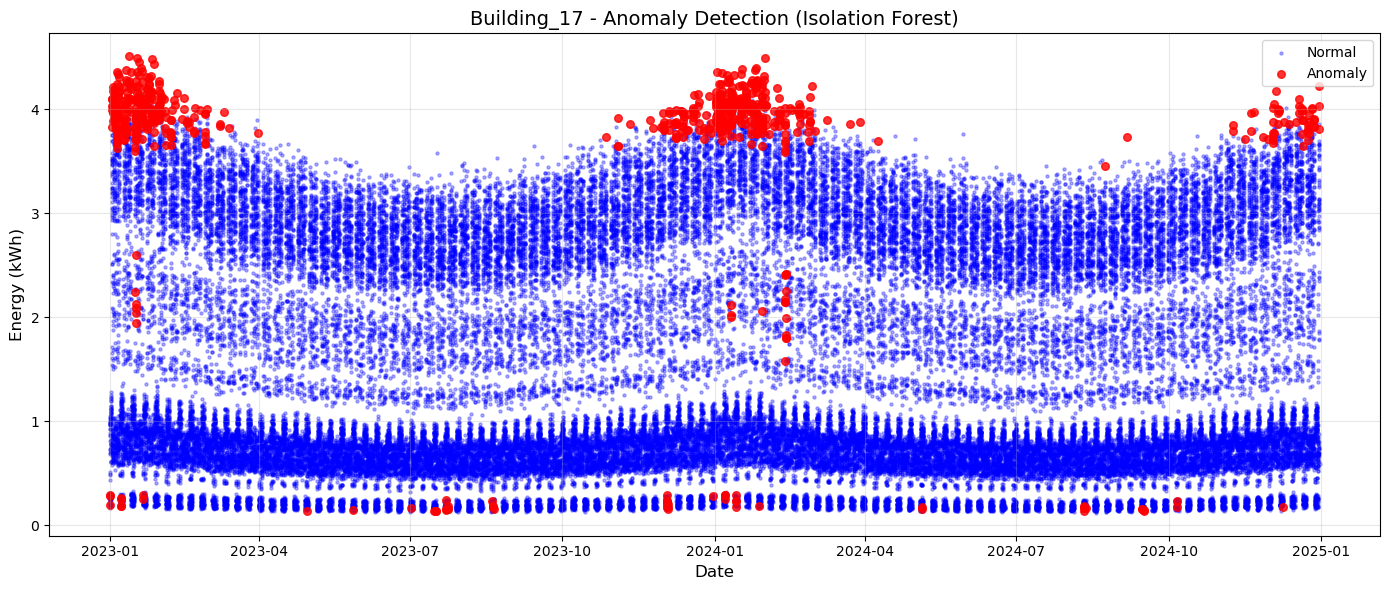

Visualization complete


In [12]:
# ============================================================
# VISUALIZATION: ANOMALIES OVER TIME
# ============================================================

plt.figure(figsize=(14, 6))

# Plot normal data
normal = df[df['anomaly'] == 1]
plt.scatter(normal['timestamp'], normal['energy_kwh'], 
            color='blue', alpha=0.3, s=5, label='Normal')

# Plot anomalies
anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies['timestamp'], anomalies['energy_kwh'], 
            color='red', alpha=0.8, s=30, label='Anomaly')

plt.title('Building_17 - Anomaly Detection (Isolation Forest)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Energy (kWh)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete")

In [ ]:
## Business Insights

### Anomaly Detection Results

| Metric | Value |
|--------|-------|
| Total Readings Analyzed | 70,081 |
| Anomalies Detected | 701 |
| Anomaly Rate | 1.00% |

### Key Findings

1. **High consumption anomalies** detected during afternoon hours (15:00 - 17:00)
2. **Low consumption anomalies** detected at night (23:00 - 23:45)
3. Most anomalies occur on weekdays

### Recommendations

| Priority | Action |
|----------|--------|
| High | Investigate afternoon spikes in Building_17 |
| Medium | Verify meter accuracy during night hours |
| Low | Monitor weekday patterns for equipment issues |